In [1]:
from argparse import ArgumentParser
from datetime import datetime
from torch.utils.data import DataLoader
import logging
import os
from models.lstm_proj_diff import LSTM
from utils.dataset import TranslateDataset
from utils.earlystopper import EarlyStopper
import pandas as pd
from logging import getLogger
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import json
from utils.warmup import WarmupScheduler

In [16]:
df_train = pd.read_parquet("data/tokenized_train.parquet")
df_eval = pd.read_parquet("data/tokenized_eval.parquet")

In [17]:
df_train.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word,en_tokens_10000,en_tokens_10000_len,pt_tokens_10000,pt_tokens_10000_len,en_tokens_50000,en_tokens_50000_len,pt_tokens_50000,pt_tokens_50000_len
0,They're gonna take you to where you can get so...,Vão levá-lo para um lugar simpático onde o pod...,54,58,7,9,"[5, 1173, 450, 746, 1199, 1074, 691, 683, 1207...",16,"[5, 6680, 3715, 469, 1031, 765, 741, 1476, 253...",17,"[5, 1173, 463, 746, 1199, 1074, 691, 683, 1207...",16,"[5, 6680, 3715, 450, 1031, 765, 741, 1476, 148...",15
1,"I've already considered my options, over and o...",Já considerei minhas opções. várias e várias v...,56,51,10,10,"[5, 631, 450, 712, 2421, 2301, 4442, 811, 1045...",17,"[5, 2175, 6138, 940, 2711, 1045, 1976, 423, 73...",14,"[5, 646, 463, 712, 2421, 13378, 811, 19105, 41...",15,"[5, 2175, 36546, 2711, 16437, 426, 7393, 387, ...",12
2,I wasn't charged with that crime.,Eu não fui acusado desse crime.,33,31,7,7,"[5, 631, 2045, 450, 387, 1580, 2781, 849, 760,...",12,"[5, 845, 721, 2655, 4067, 1936, 2452, 3508, 42...",10,"[5, 646, 2045, 463, 392, 12979, 849, 760, 3508...",11,"[5, 845, 721, 2655, 12273, 2452, 3508, 426, 6]",9
3,Do you work too much?,Tem trabalhado muito?,21,21,5,10,"[5, 1549, 691, 1545, 1191, 1364, 416, 6]",8,"[5, 1982, 1328, 4168, 941, 416, 6]",7,"[5, 1549, 691, 1545, 1191, 1364, 444, 6]",8,"[5, 1982, 18280, 941, 444, 6]",6
4,"Why, ruta lee, i do declare.","Olhe, ruta lee, estou dizendo.",28,30,8,8,"[5, 1406, 433, 949, 829, 4934, 433, 386, 687, ...",14,"[5, 3210, 433, 949, 829, 4934, 433, 1159, 2803...",11,"[5, 1406, 416, 949, 829, 4934, 416, 383, 687, ...",12,"[5, 3210, 416, 949, 829, 4934, 416, 1159, 2803...",11


In [18]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

tokenizer: Tokenizer = Tokenizer.from_file('artifacts/tokenizer_50000.json')

In [19]:
df_train.en.values[0]

"They're gonna take you to where you can get some help."

In [20]:
df_eval.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word,en_tokens_10000,en_tokens_10000_len,pt_tokens_10000,pt_tokens_10000_len,en_tokens_50000,en_tokens_50000_len,pt_tokens_50000,pt_tokens_50000_len
0,His name is on the patent. what kind of a payd...,"O nome dele está na patente, que tipo de dia d...",75,79,7,9,"[5, 3194, 1583, 696, 710, 695, 1946, 1059, 423...",22,"[5, 488, 1639, 1475, 827, 834, 1946, 864, 433,...",21,"[5, 3194, 1583, 696, 710, 695, 42893, 426, 869...",21,"[5, 572, 1639, 1475, 827, 834, 33992, 416, 693...",19
1,How does he know that song?,Como ele conhece essa musica?,27,29,5,7,"[5, 1421, 1860, 735, 870, 760, 4766, 416, 6]",9,"[5, 1445, 813, 2858, 1288, 2654, 1761, 416, 6]",9,"[5, 1421, 1860, 735, 870, 760, 4766, 444, 6]",9,"[5, 1445, 813, 2858, 1288, 32343, 444, 6]",8
2,"Vaccines. oh. well, a little evil for the grea...","- vacinas, - oh, bem, um pouco mal para o bem ...",60,58,9,8,"[5, 57, 763, 1994, 707, 423, 1655, 423, 1270, ...",22,"[5, 469, 5675, 3765, 433, 469, 1655, 433, 968,...",21,"[5, 57, 763, 1994, 707, 426, 1655, 426, 1270, ...",21,"[5, 450, 5675, 3765, 416, 450, 1655, 416, 968,...",21
3,They're an extraction team.,São uma equipe de extração.,27,27,10,9,"[5, 1173, 450, 746, 824, 895, 909, 2464, 4388,...",11,"[5, 3527, 784, 5303, 692, 895, 909, 957, 423, 6]",10,"[5, 1173, 463, 746, 824, 49631, 4388, 426, 6]",9,"[5, 3527, 784, 5303, 692, 49630, 426, 6]",8
4,"But for tom, it was business.",Mas para o tom foram negócios.,29,30,9,9,"[5, 1013, 786, 3100, 433, 732, 842, 2303, 423, 6]",10,"[5, 994, 765, 389, 3100, 2749, 4276, 423, 6]",9,"[5, 1013, 786, 3100, 416, 732, 842, 2303, 426, 6]",10,"[5, 994, 765, 390, 3100, 2749, 4276, 426, 6]",9


In [21]:
df_train.pt_tokens_50000_len.describe().to_frame()

,pt_tokens_50000_len
count,4.086243e+06
mean,1.129557e+01
std,3.090117e+00
min,5.000000e+00
25%,9.000000e+00
50%,1.100000e+01
75%,1.300000e+01
max,4.700000e+01


<Axes: >

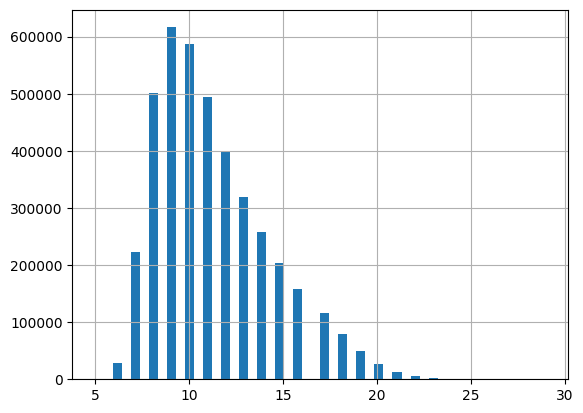

In [22]:
df_train[df_train.pt_tokens_50000_len < 30]["pt_tokens_50000_len"].hist(bins=50)

<Axes: >

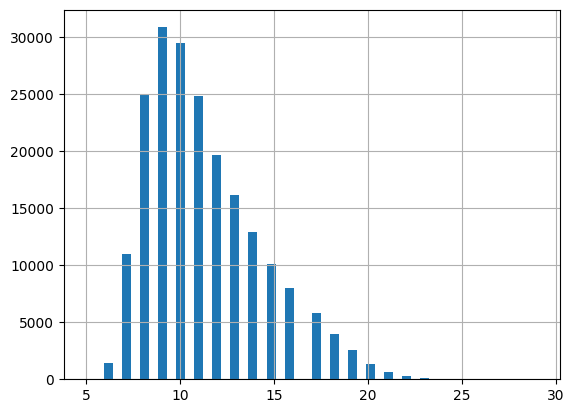

In [23]:
df_eval[df_eval.pt_tokens_50000_len < 30]["pt_tokens_50000_len"].hist(bins=50)

<Axes: >

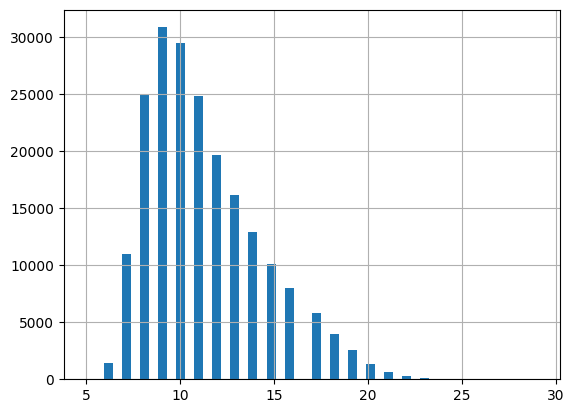

In [24]:
df_eval[df_eval.pt_tokens_50000_len < 30]["pt_tokens_50000_len"].hist(bins=50)

<Axes: >

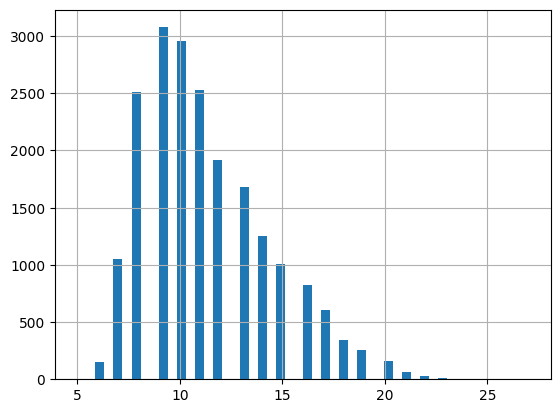

In [25]:
df_eval.loc[df_eval[f'en_tokens_50000_len'] <= 54].reset_index(drop=True).sample(frac=0.1, random_state=42)["pt_tokens_50000_len"].hist(bins=50)

In [6]:
for _, row in df_train.sample(100).iterrows():
    print('Frase inglês:', row.en)
    print('Decoding tokens inglês:', tokenizer.decode(row.en_tokens))
    print('Frase português:', row.pt)
    print('Decoding tokens português:', tokenizer.decode(row.pt_tokens))
    print('---'*80)

Frase inglês: And wish me luck, old weasel brain, it's me.


AttributeError: 'Series' object has no attribute 'en_tokens'

In [6]:
df_train.en_tokens.values[0]

array([    5,  5139,  1134,  4400,   460,   781,  4462,   460, 10969,
        1247,   939,  4087,   737,   897,  2627,   781,   739,  4424,
         460,   781,  6561,   460,   760,  1187,  2374,   460,   857,
        5959,   460, 12067,   769,   739,  6411,   770,   739,  2607,
         736,  1521,   441,     6])

In [8]:
tokenizer.decode(df_train.pt_tokens.values[0])

'Quando esses objetos se foram , eles começaram a reproduzí - los em pedra para que pudessem lembrar que estes eram os instrumentos em que os deuses vieram a eles .'